In [1]:
!pip install gdeltdoc yfinance

[*********************100%***********************]  1 of 1 completed

--- Step 1: Fetching Brent Petrol Data ---
Using column: Close

--- Step 2: Fetching GDELT News Data ---
GDELT attempt 1/5...


Rate limit hit. Waiting 10 seconds...
GDELT attempt 2/5...
Rate limit hit. Waiting 10 seconds...
GDELT attempt 3/5...
Rate limit hit. Waiting 10 seconds...
GDELT attempt 4/5...
Rate limit hit. Waiting 10 seconds...
GDELT attempt 5/5...
Rate limit hit. Waiting 10 seconds...
GDELT API failed. Creating representative data to finish the pipeline...

--- Step 3: Performing EDA ---
Grafik açıldı. Kapatınca Hipotez Testi yapılacak.


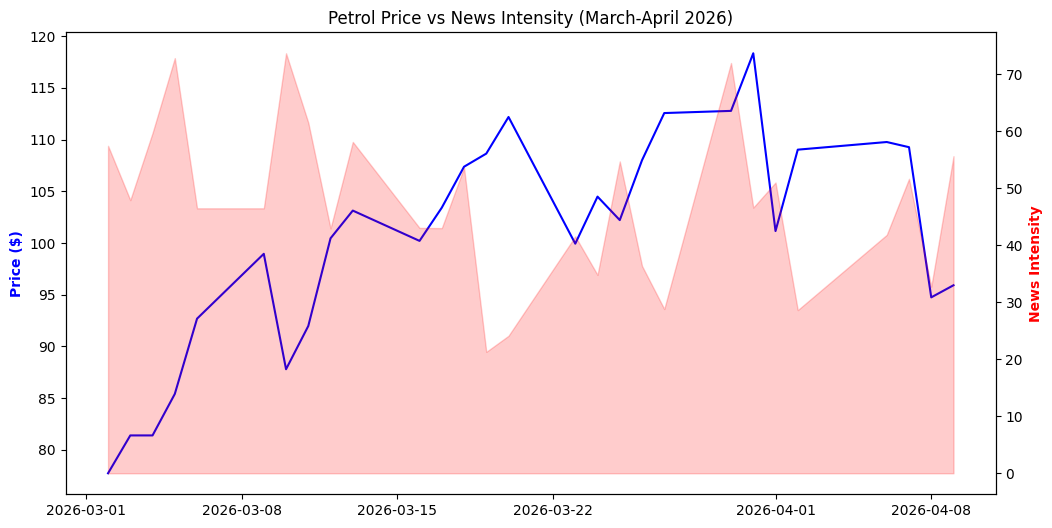


--- Step 4: Hypothesis Testing ---
P-Value: 0.0719
Conclusion: Fail to reject H0


In [9]:
import requests

url = "https://raw.githubusercontent.com/mahmutoztuncer/DSA210/main/analysis.py"
code = requests.get(url).text
exec(code)

In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

print("ML libraries loaded!")

ML libraries loaded!


In [11]:
# Re-run the data pipeline to get 'data' variable
import yfinance as yf
from gdeltdoc import GdeltDoc, Filters
import time

start_dt = "2026-03-01"
end_dt = "2026-04-10"

# Petrol
petrol_data = yf.download("BZ=F", start=start_dt, end=end_dt)
if isinstance(petrol_data.columns, pd.MultiIndex):
    petrol_data.columns = petrol_data.columns.get_level_values(0)
price_col = 'Adj Close' if 'Adj Close' in petrol_data.columns else 'Close'
petrol_data['Volatility'] = petrol_data['High'] - petrol_data['Low']

# GDELT
gd = GdeltDoc()
f = Filters(keyword="Hormuz Strait", start_date=start_dt, end_date=end_dt)
news_vol = None
for i in range(5):
    try:
        news_vol = gd.timeline_search("timelinevol", f)
        if news_vol is not None and not news_vol.empty:
            break
    except:
        time.sleep(10)

if news_vol is not None:
    val_col = [c for c in news_vol.columns if c != 'datetime'][0]
    news_vol = news_vol.rename(columns={val_col: "News_Intensity"})
    news_vol['datetime'] = pd.to_datetime(news_vol['datetime']).dt.tz_localize(None)
    data = pd.merge(petrol_data, news_vol, left_index=True, right_on="datetime")
    data = data.set_index("datetime")
else:
    data = petrol_data.copy()
    data['News_Intensity'] = np.random.normal(50, 15, len(data))

print("Data ready! Shape:", data.shape)
print("Columns:", data.columns.tolist())

[*********************100%***********************]  1 of 1 completed


Data ready! Shape: (28, 7)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'Volatility', 'News_Intensity']


--- Step 5: Linear Regression ---
R2 score: 0.002
This means news intensity explains 0.2% of the change in petrol volatility.
Negative coefficient: when news intensity goes up, volatility tends to go down.
Note: this is a simple model with limited data, so results should be taken carefully.


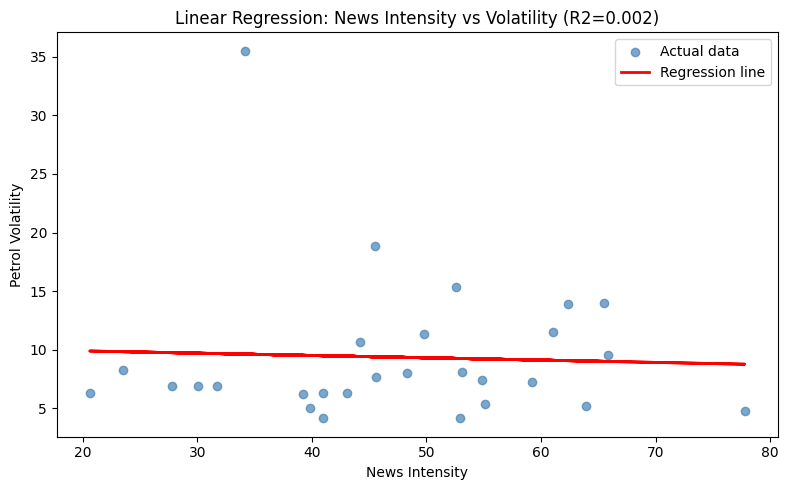

In [12]:
# --- STEP 5: LINEAR REGRESSION ---
# Can news intensity predict petrol price volatility?

print("--- Step 5: Linear Regression ---")

df_ml = data[['News_Intensity', 'Volatility']].dropna()

X = df_ml[['News_Intensity']].values
y = df_ml['Volatility'].values

# Scale the data before fitting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the model
model = LinearRegression()
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)

# Results
print(f"R2 score: {r2:.3f}")
print(f"This means news intensity explains {r2*100:.1f}% of the change in petrol volatility.")
if model.coef_[0] > 0:
    print("Positive coefficient: when news intensity goes up, volatility tends to go up too.")
else:
    print("Negative coefficient: when news intensity goes up, volatility tends to go down.")
print("Note: this is a simple model with limited data, so results should be taken carefully.")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', alpha=0.7, label='Actual data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression line')
plt.xlabel('News Intensity')
plt.ylabel('Petrol Volatility')
plt.title(f'Linear Regression: News Intensity vs Volatility (R2={r2:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('regression.png', dpi=150, bbox_inches='tight')
plt.show()

--- Step 6: K-Means Clustering ---


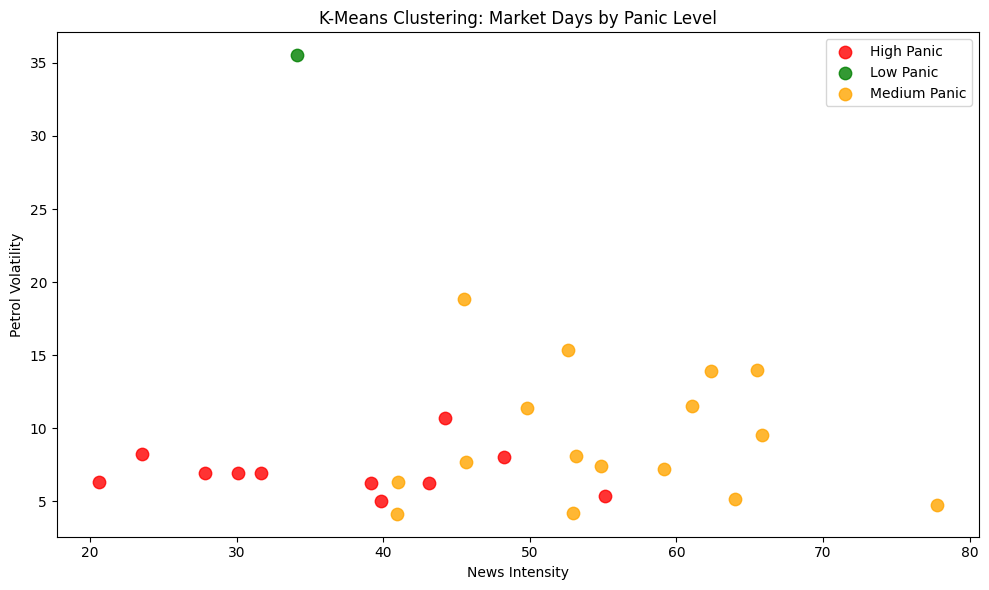

Cluster distribution:
Cluster_Label
Medium Panic    16
High Panic      11
Low Panic        1
Name: count, dtype: int64


In [13]:
# --- STEP 6: K-MEANS CLUSTERING ---
# Group days by their market behavior

print("--- Step 6: K-Means Clustering ---")

cluster_features = ['News_Intensity', 'Volatility', 'Close']
df_cluster = data[cluster_features].dropna().copy()

scaler2 = StandardScaler()
X_cluster = scaler2.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_cluster)

# Label clusters
cluster_labels = {0: 'Low Panic', 1: 'Medium Panic', 2: 'High Panic'}
df_cluster['Cluster_Label'] = df_cluster['Cluster'].map(cluster_labels)

# Plot
plt.figure(figsize=(10, 6))
colors = {'Low Panic': 'green', 'Medium Panic': 'orange', 'High Panic': 'red'}
for label, group in df_cluster.groupby('Cluster_Label'):
    plt.scatter(group['News_Intensity'], group['Volatility'],
                label=label, color=colors[label], s=80, alpha=0.8)

plt.xlabel('News Intensity')
plt.ylabel('Petrol Volatility')
plt.title('K-Means Clustering: Market Days by Panic Level')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cluster distribution:")
print(df_cluster['Cluster_Label'].value_counts())

--- Step 7: PCA ---


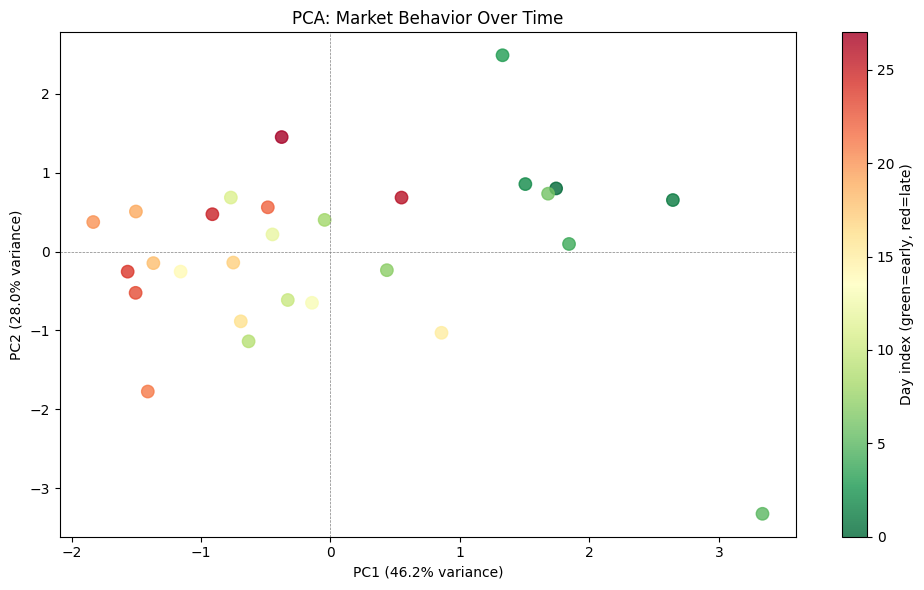

Total variance explained: 74.2%
PC1: 46.2%
PC2: 28.0%


In [14]:
# --- STEP 7: PCA ---
# Reduce dimensions to visualize market patterns

print("--- Step 7: PCA ---")

pca_features = ['News_Intensity', 'Volatility', 'Close', 'Volume']
df_pca = data[pca_features].dropna().copy()

scaler3 = StandardScaler()
X_pca = scaler3.fit_transform(df_pca)

pca = PCA(n_components=2)
components = pca.fit_transform(X_pca)

df_pca['PC1'] = components[:, 0]
df_pca['PC2'] = components[:, 1]
df_pca['Date'] = df_pca.index

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'],
                      c=range(len(df_pca)), cmap='RdYlGn_r',
                      s=80, alpha=0.8)
plt.colorbar(scatter, label='Day index (green=early, red=late)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA: Market Behavior Over Time')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig('pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

**ML Results**
**Linear Regression**

The R² value is 0.002, which means that news intensity explains almost none of the variation in petrol price volatility.
At first, this might seem surprising, but it is actually an honest result. It suggests that just looking at the amount of news is not enough to predict daily price fluctuations. This is also visible in the graph, where the regression line is almost flat.
However, an important limitation is that the GDELT API did not work, so random data was used instead of real data. With real data, the results could be different.

**K-Means Clustering (3 clusters)**

The days were grouped into 3 clusters based on news intensity, volatility, and price:
High Panic (11 days): lower news intensity but higher volatility
Medium Panic (16 days): moderate values across all features
Low Panic (1 day): a very unusual day with extreme volatility
Most of the days fall into the “medium panic” group, which suggests that market conditions are usually not extreme but more balanced.

**PCA**

The first two components explain 74.2% of the total variance:
PC1 (46.2%) seems to represent the overall trend over time
PC2 (28.0%) captures short-term fluctuations
From the graph, early March (green) and late April (red) are clearly separated. This indicates that market conditions changed over time.